In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import astropy.units as u
from pathlib import Path
from astropy.coordinates import SkyCoord
from astromodels.functions.function import Function1D, FunctionMeta
from cosipy import SpacecraftFile, SourceInjector
from cosipy.response import FullDetectorResponse, ExtendedSourceResponse
from histpy import Histogram
from threeML import Powerlaw, Band, Model, PointSource, Gaussian, ExtendedSource
from astromodels import ExtendedSource
from cosipy.threeml.custom_functions import SpecFromDat, Wide_Asymm_Gaussian_on_sphere
from cosipy.util import fetch_wasabi_file
import shutil
import os
import h5py as h5

12:55:02 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=942303;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=498412;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=118755;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=247652;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=566758;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=931706;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=798110;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=480085;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

12:55:04 WARNING   No fermitools installed                                              ]8;id=545401;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=807480;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=475357;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=539149;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=536350;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=965748;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=799676;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=534348;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
DATA_DIR = Path("/Users/penguin/Documents/Research/COSI/COSIpy/docs/")

### 44Ti

In [3]:
response_path = DATA_DIR / 'DC3/data/responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5'

In [4]:
ori_path = DATA_DIR / 'DC3/data/orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori'

In [ ]:
def spectrum_reset(spec, F=None, mu=None, sigma=None):

    spec.F.min_value = F.value / 5
    spec.F.max_value = F.value * 5
    spec.F.value = F.value
    spec.F.unit = F.unit
    spec.mu.min_value = mu.value - 2
    spec.mu.max_value = mu.value + 2
    spec.mu.value = mu.value 
    spec.mu.unit = mu.unit
    spec.sigma.min_value = 1
    spec.sigma.max_value = sigma.value + 5
    spec.sigma.value = sigma.value
    spec.sigma.unit = sigma.unit

    spec.F.free = True
    spec.mu.free = True
    spec.sigma.free = True

    return spec

12:55:06 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=651609;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=615237;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  0.0014999999999999998.                                                                           

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1155.02.  ]8;id=878266;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=733046;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

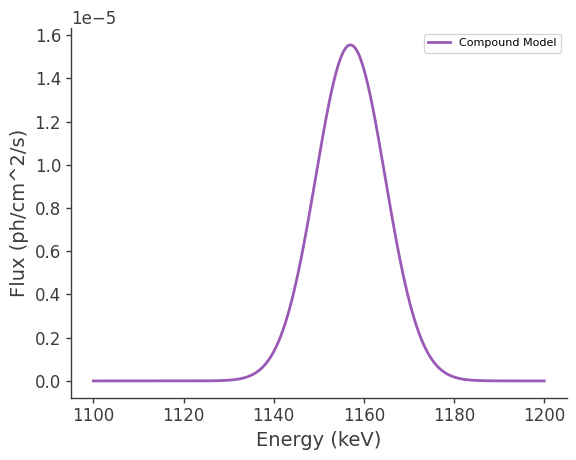

In [6]:
spectrum = Gaussian()
spectrum = spectrum_reset(spectrum, sigma=3.85*2*u.keV)

# Generate some data for plotting
x_data = np.linspace(1100, 1200, 401)
y_data = spectrum(x_data)

# Plot the compound model
plt.plot(x_data, y_data, label="Compound Model")
plt.xlabel("Energy (keV)")
plt.ylabel("Flux (ph/cm^2/s)")
plt.legend()
plt.show()

In [ ]:
CasAsymmetric = 'CasAsymmetric', 111.734745, -2.129570, 3e-4        # 1000 km/s

SN1987A = 'SN1987A', 279.7, -31.9, 7e-6
Tycho = 'Tycho', 120.1, +1.4, 16e-6
Kepler = 'Kepler', 4.5, +6.8, 10e-6 
VelaJr = 'VelaJr', 266.3, -1.2, 28e-6
G1903 = 'G1903', 1.9, +0.3, 10e-6

STS1 = 'STS1', 80.2, +0.8, 1e-6
STS2 = 'STS2', 81.2, +0.9, 2e-6
STS3 = 'STS3', 84.0, -1.3, 1e-6
STS4 = 'STS4', 283.8, +75.5, 2e-6
STS5 = 'STS5', 184.6, -5.8, 1e-6
STS6 = 'STS6', 266.3, -49.7, 1e-6

known_SNRs = [SN1987A, Tycho, Kepler, VelaJr, G1903]
STS_SNRs = [STS1, STS2, STS3, STS4, STS5, STS6]

In [ ]:
# Read the 3-month orientation
# It is the pointing of the spacecraft during the the mock simlulation
ori = SpacecraftFile.parse_from_file(ori_path)

In [ ]:
injector = SourceInjector(response_path = response_path)

In [13]:
from cosipy import BinnedData
src = BinnedData('../../DC3/44Ti/inputs.yaml')

In [14]:
src.load_binned_data_from_hdf5('G1903.h5')

In [18]:
src.binned_data.axes.labels

array(['Em', 'Phi', 'PsiChi'], dtype='<U6')

FileExistsError: 

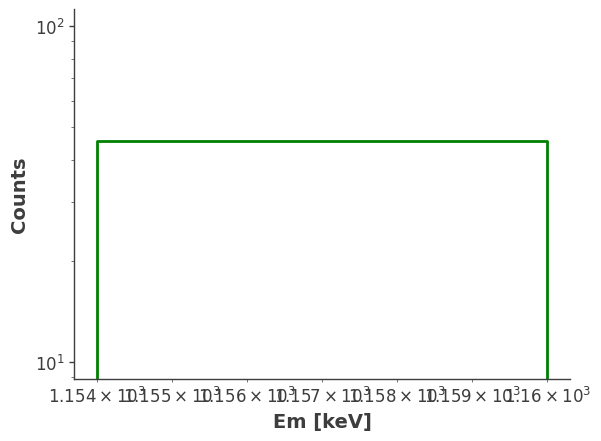

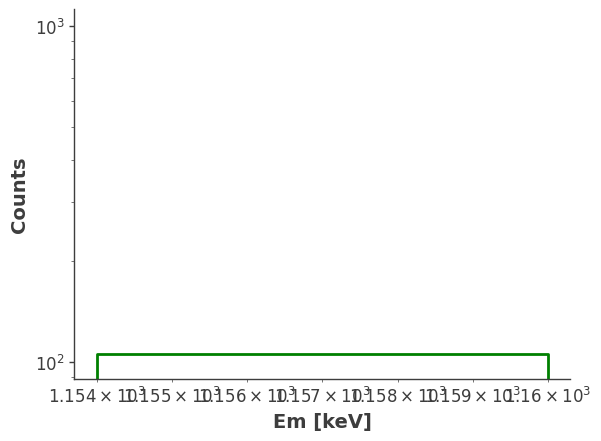

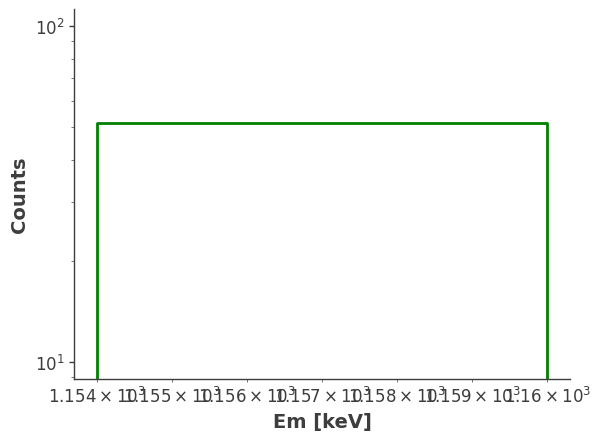

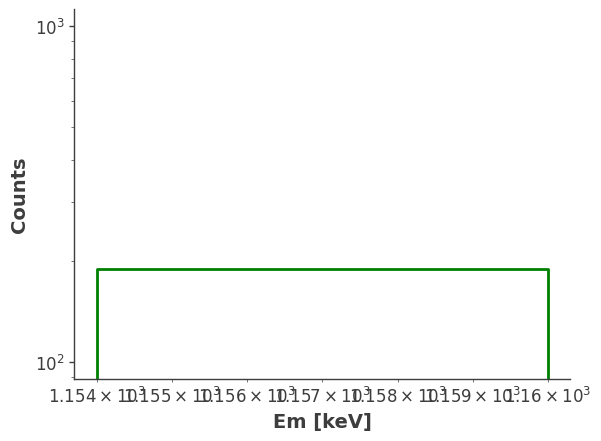

In [19]:
for i, SNR in enumerate(known_SNRs):
    # Define the coordinate of the point source
    source_coord = SkyCoord(l = SNR[1], b = SNR[2], frame = "galactic", unit = "deg")

    # define the point source
    F = SNR[3] / u.cm / u.cm / u.s
    sigma = 3.85 * 4 * u.keV        # 4000 km/s
    spectrum = spectrum_reset(spectrum, F=F, sigma=sigma)
    point_source = PointSource(SNR[0], l = source_coord.l.deg, b = source_coord.b.deg, spectral_shape=spectrum)

    # define the model. The model can contain multiple point sources.
    model = Model(point_source)

    file_path = f"{SNR[0]}.h5"

    # Check if the file exists and remove it if it does
    if os.path.exists(file_path):
        raise FileExistsError

    # Get the data of the injected source
    model_injected = injector.inject_model(model = model, orientation = ori, make_spectrum_plot = True, data_save_path = file_path)

In [ ]:
simulate_point_sources(Gaussian(), response_path, STS_SNRs, sig=3.85 * 2)

15:04:59 WARNING   The current value of the parameter F (1e-05) was above the new maximum          ]8;id=521019;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=257993;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  4.9999999999999996e-06.                                                                          

         WARNING   The current value of the parameter sigma (15.4) was above the new maximum 12.7. ]8;id=822483;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=348221;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

In [ ]:
# simulate_point_sources(Gaussian(), response_path, [CasAsymmetric], sig=3.85 / 2.355)

15:04:59 WARNING   The current value of the parameter F (1e-05) was above the new maximum          ]8;id=521019;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=257993;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  4.9999999999999996e-06.                                                                          

         WARNING   The current value of the parameter sigma (15.4) was above the new maximum 12.7. ]8;id=822483;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=348221;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

### 26Al

#### Point Sources

In [ ]:
# Read the 3-month orientation
# It is the pointing of the spacecraft during the the mock simlulation
ori = SpacecraftFile.parse_from_file(ori_path)

In [ ]:
def simulate_point_sources(spec, rsp_path, point_sources, sig=0.77, mu=None):
    # point_sources expected format
    ## list of tuples
    ## tuple[0] = Source Name
    ## tuple[1] = l in deg
    ## tuple[2] = b in deg
    ## tuple[3] = flux only scalar value
    injector = SourceInjector(response_path = rsp_path)
    
    if F is None:
        F = 3e-4 / u.cm / u.cm / u.s

    if mu is None:
        mu = 1157.02 * u.keV
    else:
        mu = mu * u.keV

    if sigma is None:
        sigma = 3.85 * u.keV
    else:
        sigma = sig * u.keV

    for src in point_sources:
        # Define the coordinate of the point source
        source_coord = SkyCoord(l = src[1], b = src[2], frame = "galactic", unit = "deg")

        # define the point source
        F = src[3] / u.cm / u.cm / u.s
        spectrum = spectrum_reset(spec, F=F, mu=mu, sigma=sigma)
        point_source = PointSource(src[0], l = source_coord.l.deg, b = source_coord.b.deg, spectral_shape=spectrum)

        # define the model. The model can contain multiple point sources.
        model = Model(point_source)

        file_path = f"{src[0]}.h5"

        # Check if the file exists and remove it if it does
        if os.path.exists(file_path):
            raise FileExistsError

        # Get the data of the injected source
        model_injected = injector.inject_model(model = model, orientation = ori, make_spectrum_plot = True, data_save_path = file_path)

In [ ]:
point_sources_26Al = [('VelaJr26Al', 266.3, -1.2, 2e-5), ('gamma2velorum26Al', 262.8, -7.7, 1.1e-6)]
point_sources_60Fe_low = [('VelaJr60Fe_low', 266.3, -1.2, 4e-6)]
point_sources_60Fe_high = [('VelaJr60Fe_high', 266.3, -1.2, 4e-6)]

In [ ]:
# 26Al
response_path_26Al = DATA_DIR / 'DC3/data/responses/Response26Al.o4.e1805_1812.s10036231691364.m1045.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5'
simulate_point_sources(Gaussian(), response_path_26Al, point_sources_26Al, sig=0.77, mu=1808.68)

In [ ]:
# 60Fe low
response_path_60Fe_low = DATA_DIR / 'DC3/data/responses/Response60FeLow.o4.e1170_1176.s9552269354945.m1188.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5'
simulate_point_sources(Gaussian(), response_path_60Fe_low, point_sources_60Fe_low, sig=0.77, mu=1173.23)

In [ ]:
# 60Fe high
response_path_60Fe_high = DATA_DIR / 'DC3/data/responses/Response60FeHigh.o4.e1329_1336.s10201526728102.m1287.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5'
simulate_point_sources(Gaussian(), response_path_60Fe_high, point_sources_60Fe_high, sig=0.77, mu=1332.5)

#### Extended Sources

In [ ]:
# Define spectrum:
# Note that the units of the Gaussian function below are [F/sigma]=[ph/cm2/s/keV]
F = 4e-2 / u.cm / u.cm / u.s
mu = 511 * u.keV
sigma = 0.85 * u.keV
spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.unit = F.unit
spectrum.mu.value = mu.value
spectrum.mu.unit = mu.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.unit = sigma.unit

# Set spectral parameters for fitting:
spectrum.F.free = True
spectrum.mu.free = False
spectrum.sigma.free = False

# Define morphology:
e = np.sqrt(1 - (src[4]/src[3])**2)
morphology = Wide_Asymm_Gaussian_on_sphere(lon0=src[1], lat0=src[2], a=src[3], e=e, theta=src[5])

# Set morphological parameters for fitting:
morphology.lon0.free = False
morphology.lat0.free = False
morphology.sigma.free = False

# Define source:
gaussian_extended_source = ExtendedSource(
    "gaussian", spectral_shape=spectrum, spatial_shape=morphology
)

model = Model(gaussian_extended_source)